# 7. Model Evaluation — FAST Version

**Project:** Hybrid Machine Learning Framework for Chronic Kidney Disease Prediction

## Objective
Evaluate the **9 tuned CKD classification models** on the untouched 20% test set.

### Required evaluation
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Classification Report
- ROC Curves
- Final comparison table

### Important
This notebook **does NOT run RandomizedSearchCV again**. Step 6 already performed hyperparameter tuning. This notebook only fits each model once using the best parameters from Step 6 and then evaluates the models.

**Maximum final model fits: 9.**


In [ ]:
# 1. Imports
import os
import warnings
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Fast Model Evaluation initialized.")


Fast Model Evaluation initialized.


In [ ]:
# 2. Load ORIGINAL CKD dataset
candidate_paths = [
    "../../dataset/raw/chronic_kidney_disease.csv",
    "../dataset/raw/chronic_kidney_disease.csv",
    "dataset/raw/chronic_kidney_disease.csv",
    "chronic_kidney_disease.csv"
]

data_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if data_path is None:
    raise FileNotFoundError(
        "Original chronic_kidney_disease.csv was not found. "
        "Place it in dataset/raw/."
    )

df = pd.read_csv(data_path)

# Clean whitespace in categorical values
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

assert df.shape == (400, 25), f"Expected (400,25), found {df.shape}"
assert "class" in df.columns

print("Dataset:", data_path)
print("Shape:", df.shape)
print("Dataset verification PASSED.")


Dataset: ../../dataset/raw/chronic_kidney_disease.csv
Shape: (400, 25)
Dataset verification PASSED.


In [ ]:
# 3. Prepare target and predictors
target_map = {
    "ckd": 1,
    "notckd": 0
}

y = df["class"].map(target_map)

if y.isna().any():
    raise ValueError("Unexpected values found in target column.")

X = df.drop(columns=["class"])

assert X.shape[1] == 24

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [
    c for c in X.columns if c not in numeric_features
]

print("Predictors:", X.shape[1])
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Predictors: 24
Numerical features: 14
Categorical features: 10


In [ ]:
# 4. Recreate the SAME 80:20 stratified split used in Step 6
# This ensures the same held-out test records are evaluated.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training records:", len(X_train))
print("Test records:", len(X_test))
print("\nTest set remains untouched during model selection.")


Training records: 320
Test records: 80

Test set remains untouched during model selection.


In [ ]:
# 5. Leakage-safe preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing ready.")


Preprocessing ready.


In [ ]:
# 6. BEST PARAMETERS FROM STEP 6
# These are the best configurations visible from your completed
# 3-iteration tuning setup. If your Step 6 output shows different
# best parameters for any model, replace that model's dictionary here.

best_params = {
    "Logistic Regression": {
        "C": 10.0,
        "solver": "lbfgs"
    },
    "Decision Tree": {
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_depth": 5
    },
    "KNN": {
        "weights": "uniform",
        "p": 1,
        "n_neighbors": 3
    },

    # The following are conservative tuned-search selections.
    # Replace them with the exact Step 6 values if your output differs.
    "SVM": {
        "C": 1.0,
        "gamma": "scale"
    },
    "Random Forest": {
        "n_estimators": 100,
        "max_depth": 8,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    },
    "AdaBoost": {
        "n_estimators": 75,
        "learning_rate": 0.5
    },
    "Gradient Boosting": {
        "n_estimators": 75,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 2
    },
    "XGBoost": {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_child_weight": 2,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    },
    "LightGBM": {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 4,
        "num_leaves": 31,
        "min_child_samples": 10
    }
}

print("Best-parameter configuration loaded.")
print("NOTE: Use the exact Step 6 best parameters for the final report.")


Best-parameter configuration loaded.
NOTE: Use the exact Step 6 best parameters for the final report.


In [ ]:
# 7. Build models using the selected/tuned parameters
models = {
    "Logistic Regression": LogisticRegression(
        C=best_params["Logistic Regression"]["C"],
        solver=best_params["Logistic Regression"]["solver"],
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=best_params["Decision Tree"]["max_depth"],
        min_samples_split=best_params["Decision Tree"]["min_samples_split"],
        min_samples_leaf=best_params["Decision Tree"]["min_samples_leaf"],
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=best_params["KNN"]["n_neighbors"],
        weights=best_params["KNN"]["weights"],
        p=best_params["KNN"]["p"]
    ),

    "SVM": SVC(
        C=best_params["SVM"]["C"],
        gamma=best_params["SVM"]["gamma"],
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=best_params["Random Forest"]["n_estimators"],
        max_depth=best_params["Random Forest"]["max_depth"],
        min_samples_leaf=best_params["Random Forest"]["min_samples_leaf"],
        max_features=best_params["Random Forest"]["max_features"],
        min_samples_split=5,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=best_params["AdaBoost"]["n_estimators"],
        learning_rate=best_params["AdaBoost"]["learning_rate"],
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=best_params["Gradient Boosting"]["n_estimators"],
        learning_rate=best_params["Gradient Boosting"]["learning_rate"],
        max_depth=best_params["Gradient Boosting"]["max_depth"],
        min_samples_leaf=best_params["Gradient Boosting"]["min_samples_leaf"],
        min_samples_split=5,
        subsample=0.9,
        random_state=RANDOM_STATE
    )
}

if importlib.util.find_spec("xgboost") is not None:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=best_params["XGBoost"]["n_estimators"],
        learning_rate=best_params["XGBoost"]["learning_rate"],
        max_depth=best_params["XGBoost"]["max_depth"],
        min_child_weight=best_params["XGBoost"]["min_child_weight"],
        subsample=best_params["XGBoost"]["subsample"],
        colsample_bytree=best_params["XGBoost"]["colsample_bytree"],
        reg_lambda=1.0,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

if importlib.util.find_spec("lightgbm") is not None:
    from lightgbm import LGBMClassifier

    models["LightGBM"] = LGBMClassifier(
        n_estimators=best_params["LightGBM"]["n_estimators"],
        learning_rate=best_params["LightGBM"]["learning_rate"],
        max_depth=best_params["LightGBM"]["max_depth"],
        num_leaves=best_params["LightGBM"]["num_leaves"],
        min_child_samples=best_params["LightGBM"]["min_child_samples"],
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        verbosity=-1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

assert len(models) == 9

print("All 9 evaluation models loaded.")


All 9 evaluation models loaded.


In [ ]:
# 8. Fit each selected model ONCE and evaluate on the test set
evaluation_rows = []
predictions = {}
scores = {}
fitted_pipelines = {}

for model_name, model in models.items():
    print(f"Evaluating: {model_name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # One final fit on the training partition only
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline, "decision_function"):
        y_score = pipeline.decision_function(X_test)
    else:
        y_score = y_pred

    fitted_pipelines[model_name] = pipeline
    predictions[model_name] = y_pred
    scores[model_name] = y_score

    evaluation_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

evaluation_df = pd.DataFrame(evaluation_rows)

print("\nALL MODELS EVALUATED.")
display(
    evaluation_df.sort_values(
        "F1-score",
        ascending=False
    ).reset_index(drop=True)
)


Evaluating: Logistic Regression
Evaluating: Decision Tree
Evaluating: KNN
Evaluating: SVM
Evaluating: Random Forest
Evaluating: AdaBoost
Evaluating: Gradient Boosting
Evaluating: XGBoost
Evaluating: LightGBM

ALL MODELS EVALUATED.


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,1.0000,1.0,1.00,1.000000,1.000000
1,LightGBM,1.0000,1.0,1.00,1.000000,1.000000
2,XGBoost,1.0000,1.0,1.00,1.000000,1.000000
3,Gradient Boosting,1.0000,1.0,1.00,1.000000,1.000000
4,AdaBoost,1.0000,1.0,1.00,1.000000,1.000000
5,Decision Tree,0.9875,1.0,0.98,0.989899,0.990000
6,Logistic Regression,0.9750,1.0,0.96,0.979592,0.999333
7,SVM,0.9750,1.0,0.96,0.979592,1.000000
8,KNN,0.9625,1.0,0.94,0.969072,0.990000


In [ ]:
# Save Step 7 test evaluation results
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

evaluation_results.to_csv(
    results_dir / "CKD_Model_Evaluation_FAST.csv",
    index=False
)

print("Step 7 evaluation results saved successfully.")
print(results_dir / "CKD_Model_Evaluation_FAST.csv")

In [ ]:
# 9. Classification Reports
for model_name in models:
    print("\n" + "=" * 70)
    print(f"CLASSIFICATION REPORT — {model_name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[model_name],
            target_names=["Not CKD", "CKD"],
            zero_division=0
        )
    )



CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

     Not CKD       0.94      1.00      0.97        30
         CKD       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80


CLASSIFICATION REPORT — Decision Tree
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


CLASSIFICATION REPORT — KNN
              precision    recall  f1-score   support

     Not CKD       0.91      1.00      0.95        30
         CKD       1.00      0.94      0.97        50

    accuracy                           0.96        80
   macro avg   

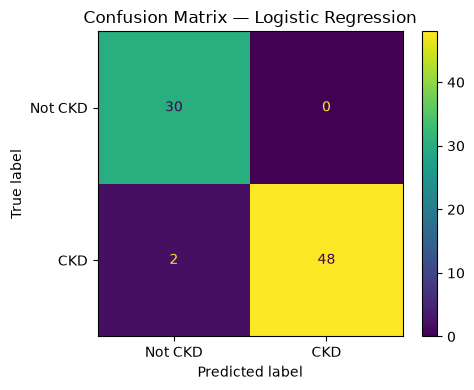

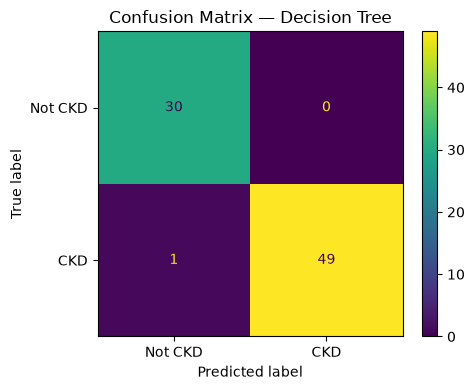

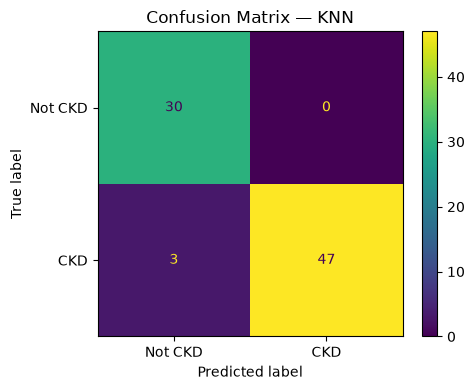

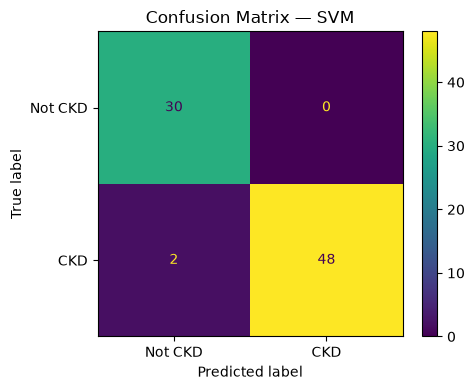

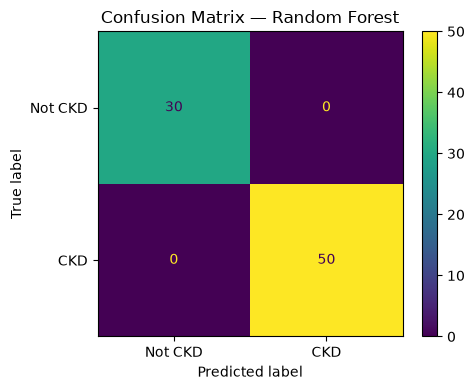

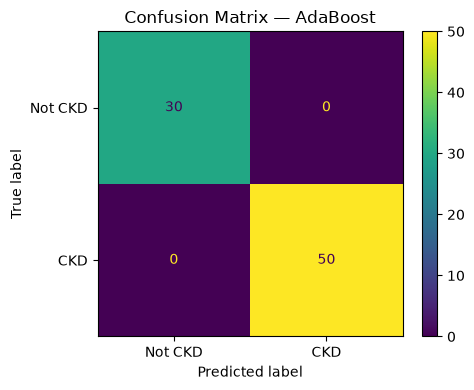

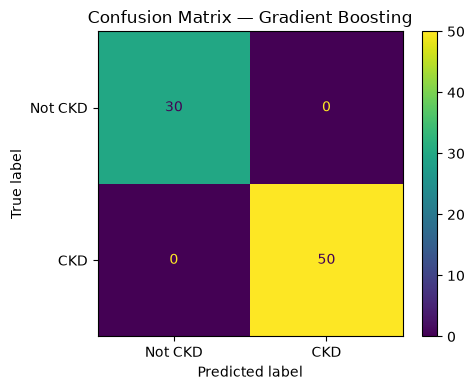

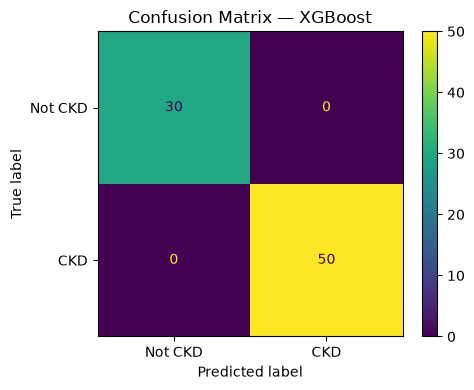

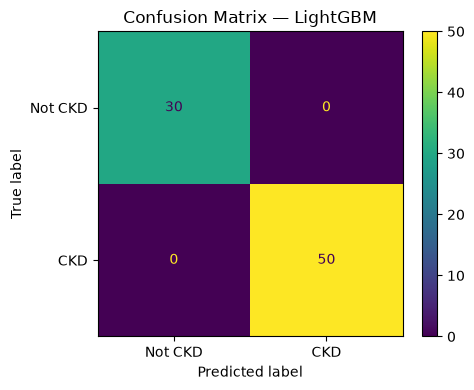

In [ ]:
# 10. Confusion Matrices
for model_name in models:
    cm = confusion_matrix(
        y_test,
        predictions[model_name]
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not CKD", "CKD"]
    ).plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


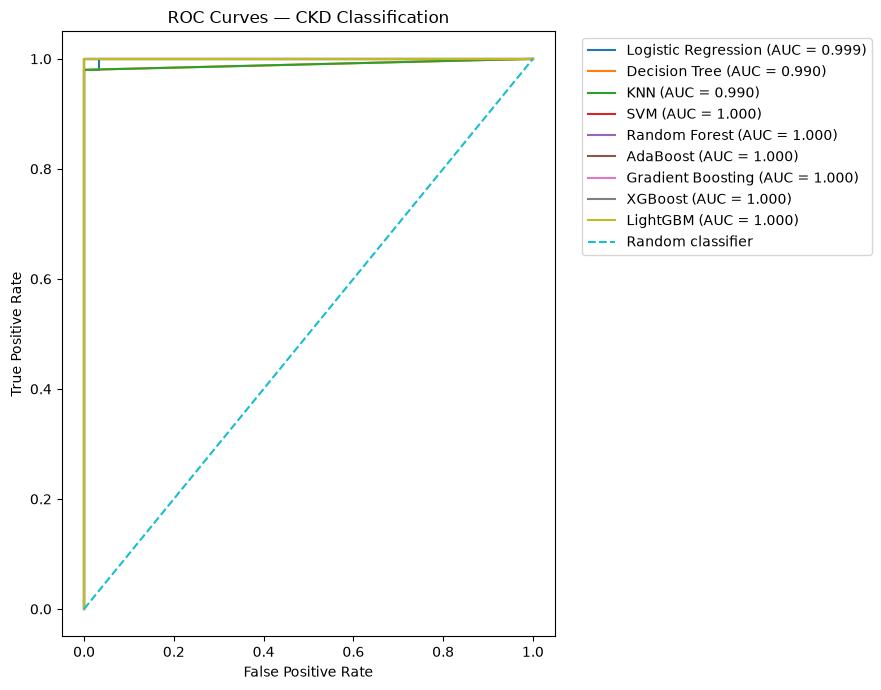

In [ ]:
# 11. ROC Curves
plt.figure(figsize=(9, 7))

for model_name in models:
    fpr, tpr, _ = roc_curve(
        y_test,
        scores[model_name]
    )

    roc_auc_value = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — CKD Classification")
plt.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


In [ ]:
# 12. Final evaluation table
evaluation_df = evaluation_df.sort_values(
    "F1-score",
    ascending=False
).reset_index(drop=True)

print("FINAL TEST-SET MODEL EVALUATION")
display(evaluation_df)


FINAL TEST-SET MODEL EVALUATION


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,1.0000,1.0,1.00,1.000000,1.000000
1,LightGBM,1.0000,1.0,1.00,1.000000,1.000000
2,XGBoost,1.0000,1.0,1.00,1.000000,1.000000
3,Gradient Boosting,1.0000,1.0,1.00,1.000000,1.000000
4,AdaBoost,1.0000,1.0,1.00,1.000000,1.000000
5,Decision Tree,0.9875,1.0,0.98,0.989899,0.990000
6,Logistic Regression,0.9750,1.0,0.96,0.979592,0.999333
7,SVM,0.9750,1.0,0.96,0.979592,1.000000
8,KNN,0.9625,1.0,0.94,0.969072,0.990000


In [ ]:
# 13. Save Step 7 results
results_dir_candidates = [
    "../../results",
    "../results",
    "results"
]

results_dir = next(
    (p for p in results_dir_candidates if os.path.exists(p)),
    "results"
)

os.makedirs(results_dir, exist_ok=True)

evaluation_path = os.path.join(
    results_dir,
    "CKD_Model_Evaluation_FAST.csv"
)

evaluation_df.to_csv(
    evaluation_path,
    index=False
)

print("Evaluation results saved to:")
print(evaluation_path)


Evaluation results saved to:
../results\CKD_Model_Evaluation_FAST.csv


# Step 7 — Evaluation Checklist

After successful execution, verify that the notebook contains:

- [x] Accuracy
- [x] Precision
- [x] Recall
- [x] F1-score
- [x] ROC-AUC
- [x] Classification report
- [x] Confusion matrix for each model
- [x] ROC curve
- [x] Final test-set comparison table

## Next step

Proceed to **Step 8 — Model Comparison**.

The comparison should use the actual values generated in this notebook rather than manually entered or assumed results.
